This notebook analyzes the final analysis-ready datasets created during the data preparation and feature engineering pipeline.

Two analytical datasets are used:

- `df_master`: order-level dataset with a grain of 1 row = 1 order
- `funnel_master`: marketing and sales funnel dataset with a grain of *1 row = 1 marketing lead

The objective of this notebook is to explore business patterns, identify meaningful relationships, evaluate customer and operational behavior, and generate insights that can later be translated into business recommendations and Power BI dashboards.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_master = pd.read_csv("../data/final/df_master.csv")
funnel_master = pd.read_csv("../data/final/funnel_master.csv")

print("df_master shape:", df_master.shape)
print("funnel_master shape:", funnel_master.shape)

df_master shape: (99441, 69)
funnel_master shape: (8000, 32)


When re-reading columns from a CSV, date columns can end up as `object` type. That is why I convert them back to `datetime`.

In [3]:
df_master_datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "customer_first_order_date",
    "customer_last_order_date"
]

for col in df_master_datetime_cols:
    df_master[col] = pd.to_datetime(
        df_master[col],
        errors="coerce"
    )

In [4]:
funnel_datetime_cols = [
    "first_contact_date",
    "won_date"
]

for col in funnel_datetime_cols:
    funnel_master[col] = pd.to_datetime(
        funnel_master[col],
        errors="coerce"
    )

These metrics provide a high-level view of the business before moving into more detailed sales, customer, logistics, and funnel analyses.

In [5]:
analysis_start = df_master["order_purchase_timestamp"].min()
analysis_end = df_master["order_purchase_timestamp"].max()

total_orders = df_master["order_id"].nunique()
total_customers = df_master["customer_unique_id"].nunique()

total_sales = df_master["order_total_price"].sum()
average_order_value = df_master["order_total_price"].mean()

average_review_score = df_master["review_score"].mean()

late_delivery_rate = df_master["is_late_delivery"].mean()

total_leads = funnel_master["mql_id"].nunique()
won_leads = funnel_master["is_won"].sum()
conversion_rate = funnel_master["is_won"].mean()

average_days_to_close = funnel_master["days_to_close"].mean()
median_days_to_close = funnel_master["days_to_close"].median()

print("=== E-COMMERCE KPIs ===")
print("Analysis period:", analysis_start, "to", analysis_end)
print("Total orders:", total_orders)
print("Unique customers:", total_customers)
print("Total sales:", round(total_sales, 2))
print("Average order value:", round(average_order_value, 2))
print("Average review score:", round(average_review_score, 2))
print("Late delivery rate:", round(late_delivery_rate * 100, 2), "%")

print("\n=== MARKETING FUNNEL KPIs ===")
print("Total leads:", total_leads)
print("Won leads:", won_leads)
print("Conversion rate:", round(conversion_rate * 100, 2), "%")
print("Average days to close:", round(average_days_to_close, 2))
print("Median days to close:", round(median_days_to_close, 2))

=== E-COMMERCE KPIs ===
Analysis period: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Total orders: 99441
Unique customers: 96096
Total sales: 13591643.7
Average order value: 137.75
Average review score: 4.09
Late delivery rate: 7.87 %

=== MARKETING FUNNEL KPIs ===
Total leads: 8000
Won leads: 842
Conversion rate: 10.52 %
Average days to close: 48.5
Median days to close: 14.0


In this section, I examine how order activity and sales value change over time. This allows me to observe growth trends, seasonality, and periods of extreme business activity.

In [6]:
monthly_sales = (
    df_master
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

monthly_sales.head()

,order_purchase_timestamp,order_count,total_sales,average_order_value
0,2016-09-01,4,267.36,89.120000
1,2016-10-01,324,49507.66,160.739156
2,2016-11-01,0,0.00,NaN
3,2016-12-01,1,10.90,10.900000
4,2017-01-01,800,120312.87,152.487795


Monthly order volume and sales value show a clear growth trend throughout the period under review.

Order activity increased significantly during 2017, followed by a higher and relatively stable level of monthly activity in the first eight months of 2018.

I also examined the sharp decline observed in September and October 2018. There are very few order records for these months; the majority were cancelled, and no price information for individual order items is included.

Therefore, I interpreted this as a limitation regarding data coverage rather than an actual decline in business performance.

Consequently, for the monthly trend analysis, I treated August 2018 as the last month with sufficiently complete data. While retaining the original records in `df_master`, I excluded the subsequent months containing incomplete data from the analysis.

In [7]:
monthly_coverage = (
    df_master
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        order_count=("order_id", "nunique"),
        orders_with_price=("order_total_price", "count"),
        total_sales=("order_total_price", "sum")
    )
    .reset_index()
)

monthly_coverage.tail(6)

,order_purchase_timestamp,order_count,orders_with_price,total_sales
20,2018-05-01,6873,6853,996517.68
21,2018-06-01,6167,6160,865124.31
22,2018-07-01,6292,6273,895507.22
23,2018-08-01,6512,6452,854686.33
24,2018-09-01,16,1,145.00
25,2018-10-01,4,0,0.00


In [8]:
df_master[
    df_master["order_purchase_timestamp"] >= "2018-08-01"
][
    [
        "order_purchase_timestamp",
        "order_status",
        "order_total_price"
    ]
].sort_values("order_purchase_timestamp").tail(30)

,order_purchase_timestamp,order_status,order_total_price
30077,2018-08-29 14:18:23,delivered,418.00
31486,2018-08-29 14:18:28,delivered,45.90
69678,2018-08-29 14:52:00,delivered,24.90
88097,2018-08-29 15:00:37,delivered,84.99
2029,2018-08-29 16:27:49,canceled,NaN
17983,2018-08-30 10:14:00,canceled,NaN
25953,2018-08-30 10:24:34,canceled,NaN
29915,2018-08-30 13:07:46,canceled,NaN
88141,2018-08-30 15:11:58,canceled,NaN
99283,2018-08-31 16:13:44,canceled,NaN


That is why I created a view named "monthly_sales_complete." This way, no data is lost and the source remains untouched; instead, we simply define the scope of analysis for a specific business question.

In [9]:
monthly_sales_complete = monthly_sales[
    monthly_sales["order_purchase_timestamp"] <= "2018-08-01"
].copy()

monthly_sales_complete.tail()

,order_purchase_timestamp,order_count,total_sales,average_order_value
19,2018-04-01,6939,996647.75,143.733451
20,2018-05-01,6873,996517.68,145.413349
21,2018-06-01,6167,865124.31,140.442258
22,2018-07-01,6292,895507.22,142.755814
23,2018-08-01,6512,854686.33,132.468433


Based on the dataframe I just created, I generated line charts showing the number of orders and total sales amounts by month.

Throughout 2017, both order volume and sales value show significant growth. From late 2017 onwards, monthly performance rises to a much higher level. In the first eight months of 2018, the number of orders hovers roughly in the 6,000–7,000 range, while monthly sales remain around 0.85–1.0 million.

In short, the overall picture shows strong growth from the early period leading into 2018, followed by relative stabilization at a high level.

The distinct peak around November 2017 is also noteworthy; I might examine that further later on.

In [10]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 1 Axes>

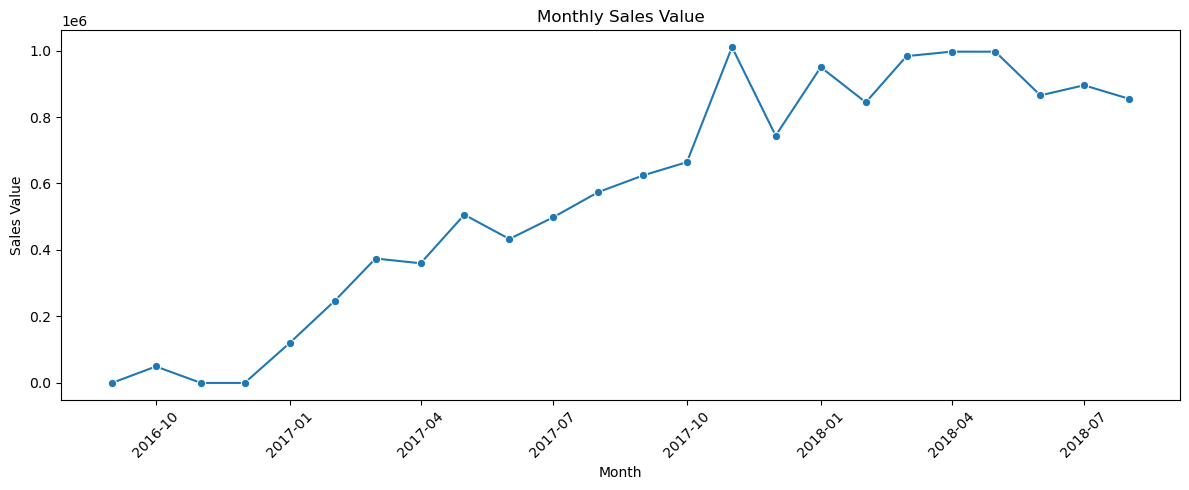

In [11]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="total_sales",
    marker="o"
)

plt.title("Monthly Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To understand whether sales growth is driven by higher spending per order or primarily by increasing order volume, I analyzed the monthly Average Order Value (AOV).

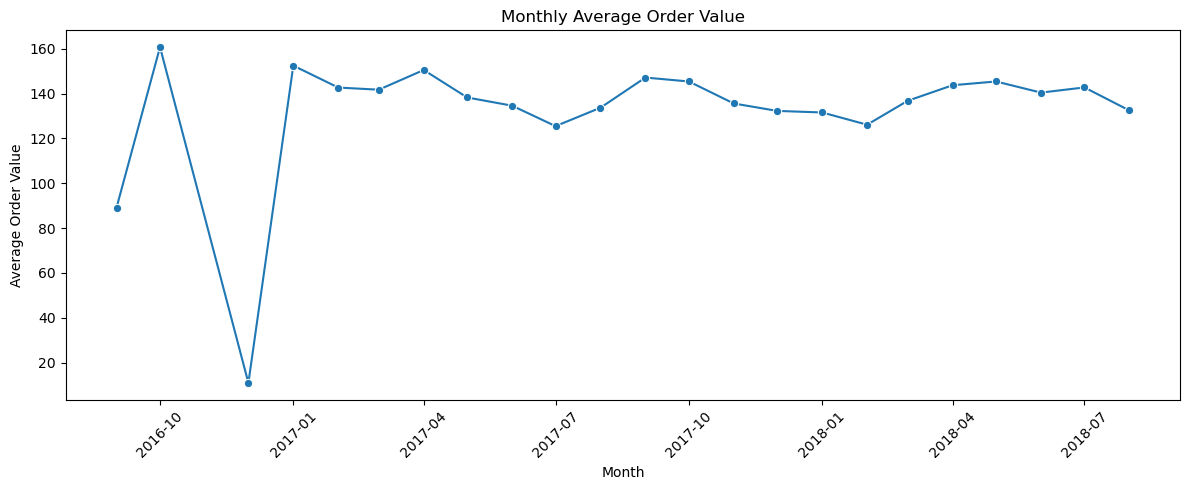

In [12]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="average_order_value",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Average Monthly Order Value has remained relatively stable throughout the dataset's primary period of activity.

Although significant fluctuations were observed in the initial months, these movements stemmed from very low order volumes.

From 2017 onwards, while monthly order volume and total sales increased substantially, the Average Order Value (AOV) generally remained within a relatively narrow range.

This indicates that the overall sales growth observed in the dataset was driven primarily by an increase in transaction volume rather than by a sustained rise in spending per order.

In [13]:
monthly_sales_complete[
    [
        "order_purchase_timestamp",
        "order_count",
        "total_sales",
        "average_order_value"
    ]
].tail(12)

,order_purchase_timestamp,order_count,total_sales,average_order_value
12,2017-09-01,4285,624401.69,147.160427
13,2017-10-01,4631,664219.43,145.407056
14,2017-11-01,7544,1010271.37,135.588695
15,2017-12-01,5673,743914.17,132.274924
16,2018-01-01,7269,950030.36,131.583152
17,2018-02-01,6728,844178.71,126.109756
18,2018-03-01,7211,983213.44,136.785398
19,2018-04-01,6939,996647.75,143.733451
20,2018-05-01,6873,996517.68,145.413349
21,2018-06-01,6167,865124.31,140.442258


I analyzed order activity on a day-by-day basis.

Order volumes are higher on weekdays compared to weekends; the highest number of orders is recorded on Mondays, while the lowest is recorded on Saturdays. Order activity generally tends to decline from the beginning to the end of the work week, followed by a marked drop over the weekend.

However, the Average Order Value remains relatively consistent across weekdays. This indicates that variations in total daily sales stem primarily from the number of transactions rather than from significant fluctuations in spending per order.

In [14]:
weekday_orders = (
    df_master
    .groupby("purchase_weekday")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

weekday_orders

,purchase_weekday,order_count,total_sales,average_order_value
0,Friday,14122,1962426.75,140.153317
1,Monday,16196,2230812.51,138.835730
2,Saturday,10887,1504018.36,139.093532
3,Sunday,11960,1589278.89,133.687659
4,Thursday,14761,2018615.78,137.893010
5,Tuesday,15963,2172647.82,137.240087
6,Wednesday,15552,2113843.59,137.040103


In [15]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_orders["purchase_weekday"] = pd.Categorical(
    weekday_orders["purchase_weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_orders = weekday_orders.sort_values(
    "purchase_weekday"
)

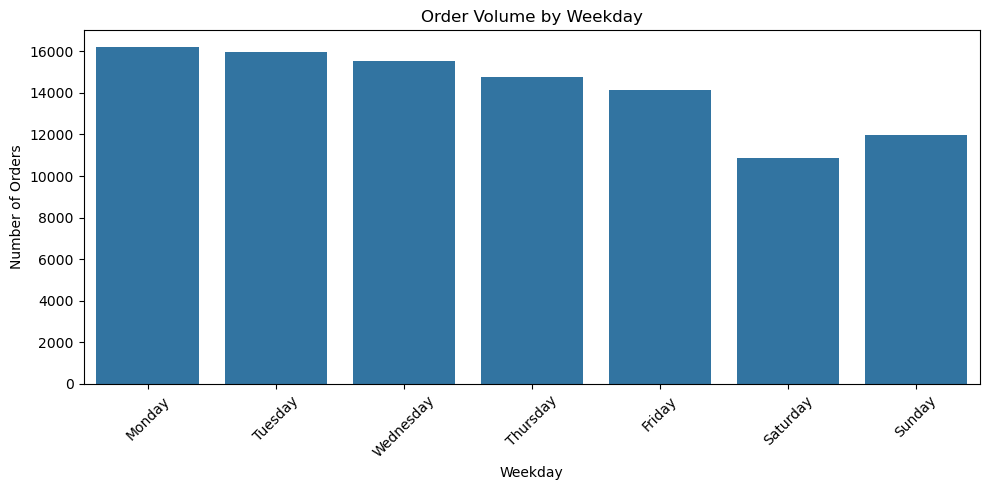

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_orders,
    x="purchase_weekday",
    y="order_count"
)

plt.title("Order Volume by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To understand when customers are most active, I categorized orders into four distinct purchasing periods. For each period, I calculated the order volume, total sales amount, and Average Order Value.

This analysis helps identify the timeframes with the highest purchasing activity and determine whether variations in sales stem primarily from transaction volume or from changes in the amount spent per order.

While order volume peaks in the afternoon, purchasing activity is significantly lower during the evening hours.

Average Order Value also varies across these periods, reaching its highest level in the afternoon and its lowest at night. However, the variations in average order value are relatively modest compared to the differences in transaction volume.

This indicates that the higher sales figures recorded in the afternoon and evening are primarily driven by increased purchasing activity rather than by significant fluctuations in spending per order.

In [17]:
purchase_period_summary = (
    df_master
    .groupby("purchase_period")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

purchase_period_summary

,purchase_period,order_count,total_sales,average_order_value
0,Afternoon,38361,5344650.00,140.430647
1,Evening,34100,4650802.19,137.337650
2,Morning,22240,2992326.39,135.749507
3,Night,4740,603865.12,128.481940


In [18]:
period_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

purchase_period_summary["purchase_period"] = pd.Categorical(
    purchase_period_summary["purchase_period"],
    categories=period_order,
    ordered=True
)

purchase_period_summary = purchase_period_summary.sort_values(
    "purchase_period"
)

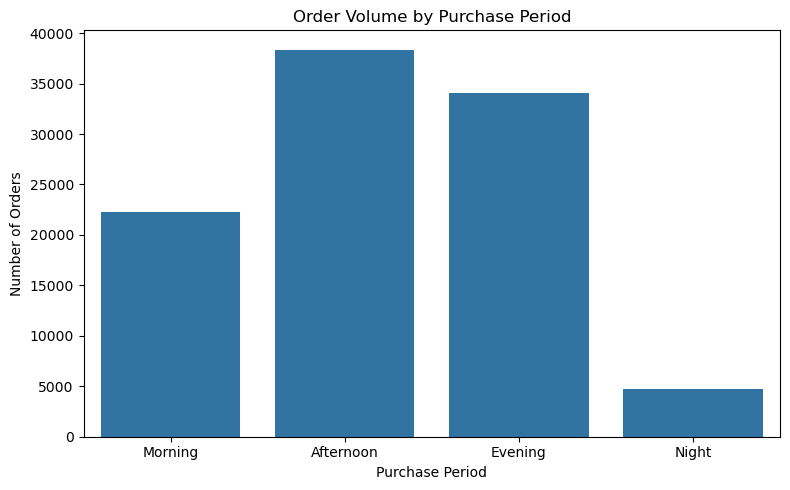

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=purchase_period_summary,
    x="purchase_period",
    y="order_count"
)

plt.title("Order Volume by Purchase Period")
plt.xlabel("Purchase Period")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

I am creating a view at the customer grain to perform business analyses regarding customer behavior; since the grain of `df_master` is at the order level, this could lead to the same customer appearing multiple times during customer analysis.

In [20]:
customer_view = (
    df_master[
        [
            "customer_unique_id",
            "customer_order_count",
            "customer_total_spend",
            "customer_avg_order_value",
            "customer_lifetime_days",
            "customer_recency_days",
            "R_score",
            "F_score",
            "M_score",
            "RFM_score",
            "RFM_segment"
        ]
    ]
    .drop_duplicates(subset="customer_unique_id")
    .copy()
)

print("Customer-level rows:", len(customer_view))
print(
    "Unique customers:",
    customer_view["customer_unique_id"].nunique()
)

Customer-level rows: 96096
Unique customers: 96096


In [21]:
customer_view["order_frequency_group"] = pd.cut(
    customer_view["customer_order_count"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=["1", "2", "3", "4", "5+"]
)


frequency_group_summary = (
    customer_view["order_frequency_group"]
    .value_counts()
    .sort_index()
)

frequency_group_summary

order_frequency_group
1     93099
2      2745
3       203
4        30
5+       19
Name: count, dtype: int64

Customer purchase frequency is heavily concentrated among one-time buyers.

This indicates that customer loyalty was limited during the period under review and that the increase in transaction volume was driven largely by one-time customers rather than by repeat purchasing behavior.

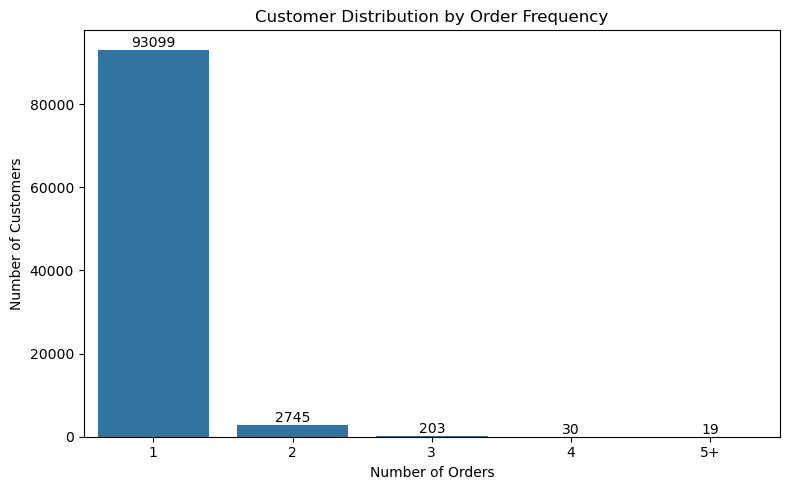

In [22]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=frequency_group_summary.index,
    y=frequency_group_summary.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.title("Customer Distribution by Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

This analysis examines whether customer churn is evenly distributed or concentrated among a smaller segment of high-spending customers.

In addition to a standard descriptive analysis, I also examined the 90th, 95th, and 99th percentiles to better understand the upper tail of customer spending.

Customer spending exhibits a distribution that is significantly right-skewed.

The median spending amount is substantially lower than the mean; this indicates that a small number of high-spending customers are pulling the average upward.

The vast majority of customers have much lower total spending levels:

- 50% spend 89.90 or less,
- 90% spend 284 or less,
- 95% spend 422 or less,
- and 99% spend approximately 1,014 or less.

In [23]:
customer_view["customer_total_spend"].describe(
    percentiles=[0.90, 0.95, 0.99]
)

count    95420.000000
mean       142.440198
std        217.656355
min          0.850000
50%         89.900000
90%        284.000000
95%        422.000000
99%       1013.593400
max      13440.000000
Name: customer_total_spend, dtype: float64

To better interpret the main distribution, I visualized the histogram up to the 99th percentile. High-spending customers have been retained in the dataset and can be analyzed separately as "high-value customers."

99th percentile: 1013.59
Customers shown: 94465


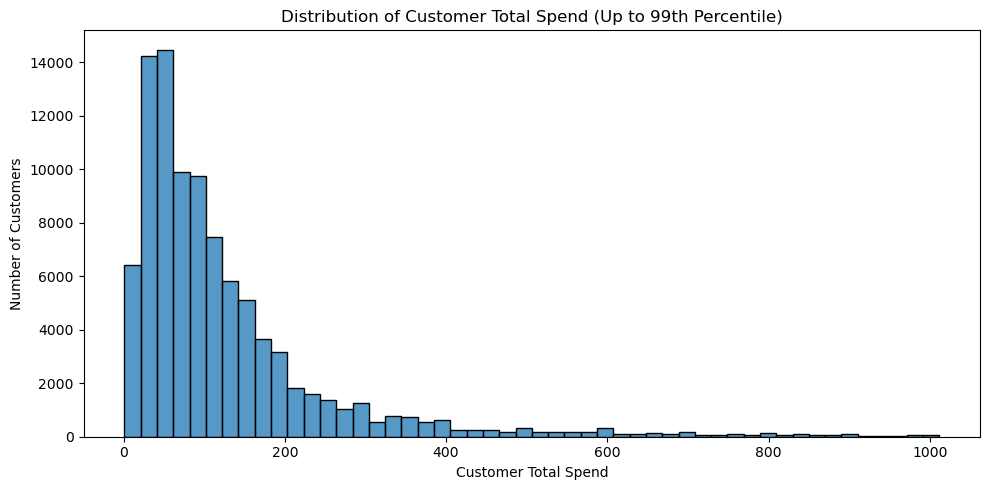

In [24]:
spend_99 = customer_view["customer_total_spend"].quantile(0.99)

customer_spend_main = customer_view[
    customer_view["customer_total_spend"] <= spend_99
].copy()

print("99th percentile:", round(spend_99, 2))
print("Customers shown:", len(customer_spend_main))

plt.figure(figsize=(10, 5))

sns.histplot(
    data=customer_spend_main,
    x="customer_total_spend",
    bins=50
)

plt.title("Distribution of Customer Total Spend (Up to 99th Percentile)")
plt.xlabel("Customer Total Spend")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [25]:
high_spenders = customer_view[
    customer_view["customer_total_spend"] > spend_99
]

print("Customers above 99th percentile:", len(high_spenders))
print(
    high_spenders["customer_total_spend"]
    .describe()
)

Customers above 99th percentile: 955
count      955.000000
mean      1640.598712
std        812.232381
min       1014.000000
25%       1199.625000
50%       1399.000000
75%       1849.950000
max      13440.000000
Name: customer_total_spend, dtype: float64


Since the vast majority of customers placed only a single order, their `customer_lifetime_days` value is naturally zero.

Therefore, to gain a more meaningful perspective on ongoing customer relationships, I analyzed customer lifetime specifically for repeat customers.

The analysis examines the number of days between the first and last recorded purchases for each repeat customer.

In [26]:
repeat_customers = customer_view.query(
    "customer_order_count > 1"
).copy()

print("Repeat customers:", len(repeat_customers))

print(
    repeat_customers["customer_lifetime_days"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)

Repeat customers: 2997
count    2997.000000
mean       86.941942
std       115.571162
min         0.000000
25%         0.000000
50%        33.000000
75%       138.000000
90%       266.000000
95%       338.000000
max       633.000000
Name: customer_lifetime_days, dtype: float64



The distribution is strongly right-skewed. Most repeat customers return within a relatively short period, while a smaller group maintains purchasing activity over several months or even more than a year.

I also observed that the first quartile is 0 days, which indicates that at least 25% of repeat customers placed multiple orders on the same day.

The longest observed customer lifetime is 633 days, representing the time between that customer's first and last recorded orders.

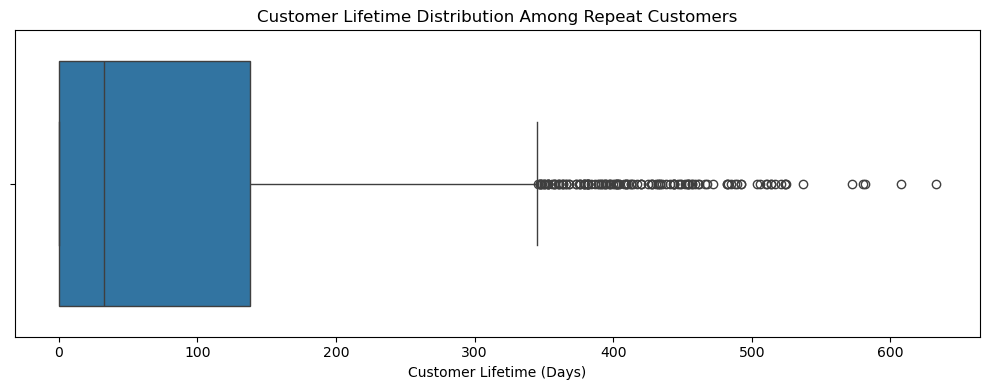

In [27]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=repeat_customers,
    x="customer_lifetime_days"
)

plt.title("Customer Lifetime Distribution Among Repeat Customers")
plt.xlabel("Customer Lifetime (Days)")
plt.tight_layout()
plt.show()


I analyzed customer recency relative to the dataset reference date to understand how recently customers made their last recorded purchase.


In [28]:
customer_view["customer_recency_days"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

count    96096.000000
mean       288.735691
std        153.414676
min          1.000000
10%         91.000000
25%        164.000000
50%        269.000000
75%        398.000000
90%        517.000000
max        773.000000
Name: customer_recency_days, dtype: float64

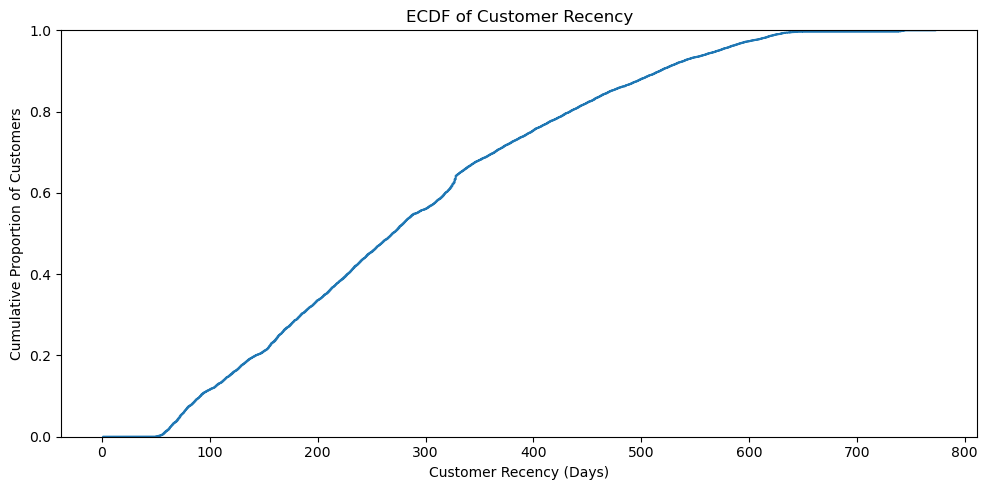

In [29]:
plt.figure(figsize=(10, 5))

sns.ecdfplot(
    data=customer_view,
    x="customer_recency_days"
)

plt.title("ECDF of Customer Recency")
plt.xlabel("Customer Recency (Days)")
plt.ylabel("Cumulative Proportion of Customers")
plt.tight_layout()
plt.show()


I analyzed the customer base using the final RFM segments created during feature engineering.

For each segment, I calculated:

- the number of customers,
- average recency,
- average purchase frequency,
- and average monetary value.

This comparison allows me to understand not only the size of each segment but also the behavioral characteristics that distinguish them.

In [30]:
rfm_segment_summary = (
    customer_view
    .groupby("RFM_segment")
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        avg_recency=("customer_recency_days", "mean"),
        avg_frequency=("customer_order_count", "mean"),
        avg_monetary=("customer_total_spend", "mean")
    )
    .reset_index()
    .sort_values("customer_count", ascending=False)
)

rfm_segment_summary

,RFM_segment,customer_count,avg_recency,avg_frequency,avg_monetary
2,Hibernating,23272,446.254770,1.013579,56.149507
0,Big Spenders,22205,386.618780,1.061338,272.508831
7,Potential Loyalists,21784,141.581160,1.000000,212.145438
6,New / Recent Customers,15426,140.078374,1.000000,40.400838
5,Need Attention,11422,270.929522,1.012169,55.866537
1,Champions,1002,138.500998,2.196607,327.939611
3,Insufficient Data,676,378.670118,1.013314,NaN
4,Loyal Customers,309,135.485437,2.035599,73.045858


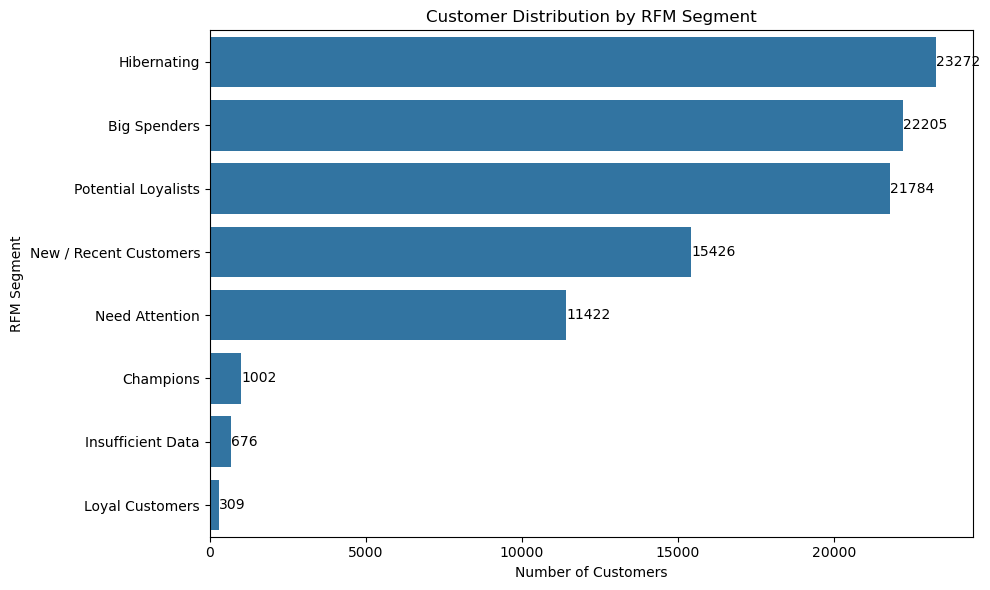

In [31]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=rfm_segment_summary,
    y="RFM_segment",
    x="customer_count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")
plt.tight_layout()
plt.show()

I analyzed the monetary contribution of each RFM segment to understand how customer value is distributed across the customer base.

This analysis allows me to distinguish between segments that are large in customer count and segments that contribute disproportionately high monetary value.

Comparing customer share with monetary share helps identify strategically important segments. A segment may represent a relatively small portion of the customer base but still generate a meaningful share of total value, while a large segment may contribute less value per customer.

In [32]:
rfm_value_summary = (
    customer_view
    .groupby("RFM_segment")
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        total_monetary=("customer_total_spend", "sum"),
        avg_monetary=("customer_total_spend", "mean")
    )
    .reset_index()
)

rfm_value_summary["monetary_share_pct"] = (
    rfm_value_summary["total_monetary"]
    / rfm_value_summary["total_monetary"].sum()
    * 100
)

rfm_value_summary = rfm_value_summary.sort_values(
    "total_monetary",
    ascending=False
)

rfm_value_summary

,RFM_segment,customer_count,total_monetary,avg_monetary,monetary_share_pct
0,Big Spenders,22205,6051058.59,272.508831,44.520433
7,Potential Loyalists,21784,4621376.23,212.145438,34.001599
2,Hibernating,23272,1306711.32,56.149507,9.614079
5,Need Attention,11422,638107.58,55.866537,4.694852
6,New / Recent Customers,15426,623223.32,40.400838,4.585342
1,Champions,1002,328595.49,327.939611,2.417629
4,Loyal Customers,309,22571.17,73.045858,0.166067
3,Insufficient Data,676,0.00,NaN,0.000000


I found that `Big Spenders` and `Potential Loyalists` dominate overall customer value. Together, they account for approximately 78.5% of total recorded customer spending.

Although `Champions` have the highest average monetary value per customer, they represent a much smaller segment. As a result, their total contribution is lower than that of the larger high-value segments.

In contrast, `Hibernating` customers represent a large portion of the customer base but contribute a much smaller share of total monetary value.

This comparison shows that segment size alone does not determine business value. I therefore use both customer volume and monetary contribution when identifying priority customer groups.

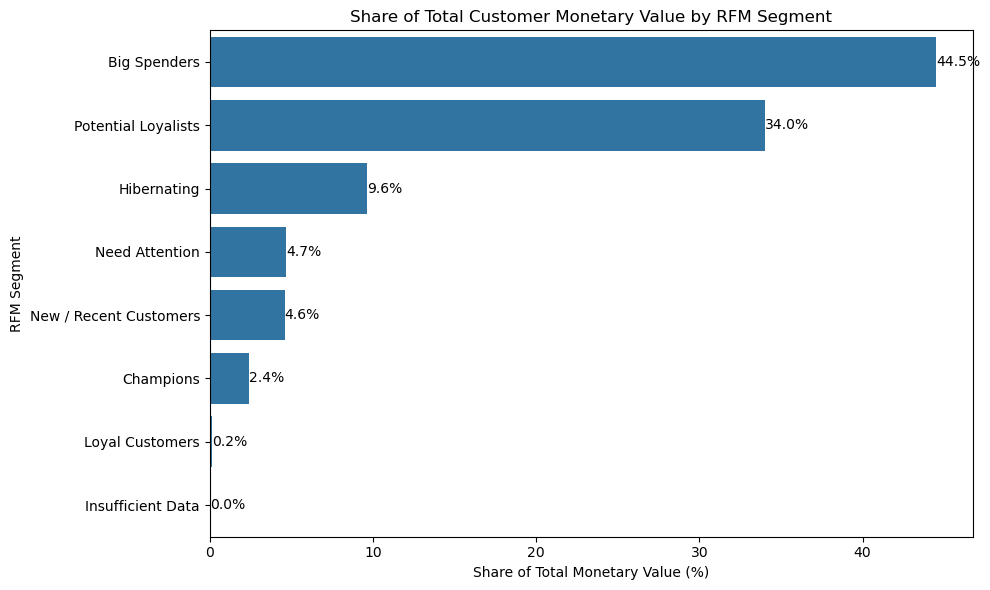

In [33]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=rfm_value_summary,
    y="RFM_segment",
    x="monetary_share_pct"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Share of Total Customer Monetary Value by RFM Segment")
plt.xlabel("Share of Total Monetary Value (%)")
plt.ylabel("RFM Segment")
plt.tight_layout()
plt.show()

I analyze delivery performance to understand how efficiently orders move through the fulfillment process and how logistics may affect customer experience.

I restricted the delivery-time analysis to completed deliveries because canceled or unfinished orders do not have a meaningful final delivery duration.

Since a small number of unusually long deliveries can compress the main distribution, I visualize delivery times up to the 99th percentile while preserving all original records in the underlying dataset.


In [34]:
delivered_orders = (
    df_master
    .query("order_status == 'delivered'")
    .copy()
)

print("Delivered orders:", len(delivered_orders))

print(
    delivered_orders["delivery_time_days"]
    .describe(percentiles=[0.90, 0.95, 0.99])
)

Delivered orders: 96478
count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
50%         10.217477
90%         23.096377
95%         29.274046
99%         46.050262
max        209.628611
Name: delivery_time_days, dtype: float64


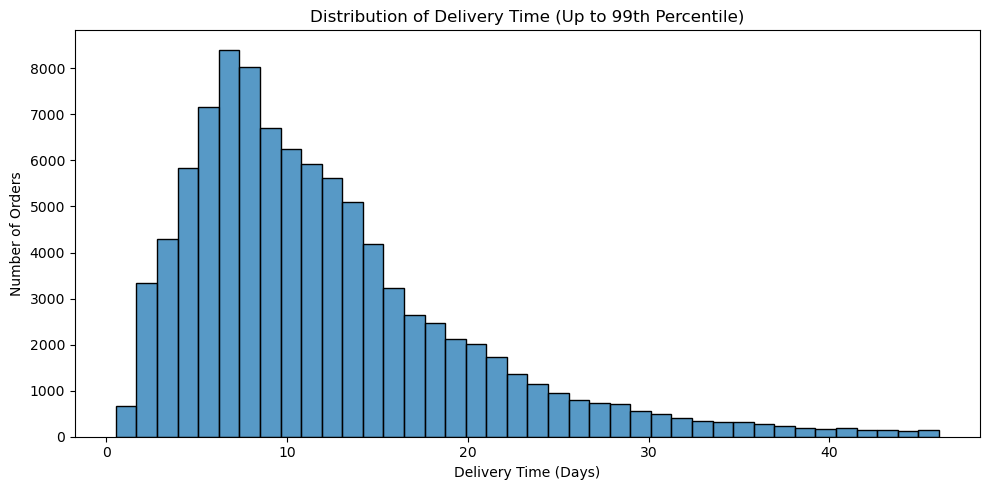

In [35]:
delivery_99 = delivered_orders["delivery_time_days"].quantile(0.99)

delivery_main = delivered_orders[
    delivered_orders["delivery_time_days"] <= delivery_99
].copy()

plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivery_main,
    x="delivery_time_days",
    bins=40
)

plt.title("Distribution of Delivery Time (Up to 99th Percentile)")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

I compared average review scores between late and on-time deliveries to evaluate whether delivery performance is associated with customer satisfaction.

I grouped orders by `is_late_delivery` and calculated both the number of orders and the average review score for each group.

In [37]:
late_review_summary = (
    df_master
    .groupby("is_late_delivery")
    .agg(
        order_count=("order_id", "nunique"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

late_review_summary

,is_late_delivery,order_count,avg_review_score
0,False,91614,4.214304
1,True,7827,2.565388



I found a substantial difference between the two groups

This difference of about 1.65 points on a 5-point scale indicates a strong negative association between late delivery and customer satisfaction.

Although this analysis does not establish causality, the result suggests that delivery reliability is an important operational factor associated with customer experience.

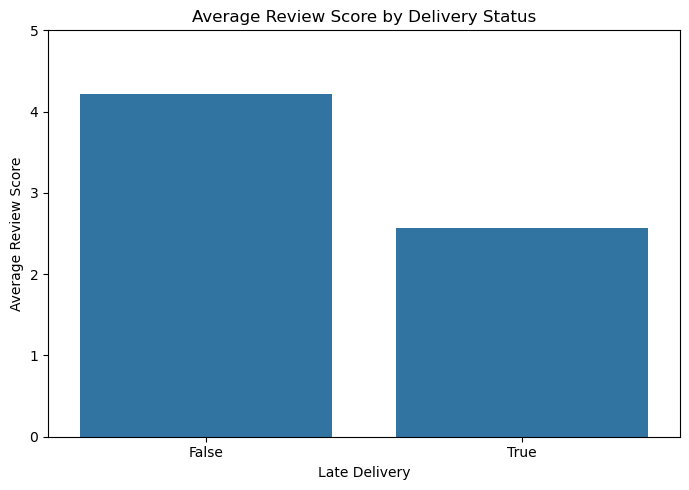

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=late_review_summary,
    x="is_late_delivery",
    y="avg_review_score"
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Late Delivery")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [39]:
freight_summary = df_master[
    [
        "order_total_freight",
        "freight_ratio"
    ]
].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)

freight_summary

,order_total_freight,freight_ratio
count,98666.000000,98666.000000
mean,22.823562,0.308389
std,21.650909,0.314762
min,0.000000,0.000000
50%,17.170000,0.224374
90%,39.495000,0.622503
95%,54.960000,0.839355
99%,104.983500,1.461909
max,1794.960000,21.447059


In [40]:
freight_review_corr = (
    df_master[
        [
            "freight_ratio",
            "review_score"
        ]
    ]
    .corr()
)

freight_review_corr

,freight_ratio,review_score
freight_ratio,1.000000,-0.021107
review_score,-0.021107,1.000000


In [41]:
freight_ratio_view = df_master[
    [
        "freight_ratio",
        "review_score"
    ]
].dropna().copy()

freight_ratio_view["freight_ratio_quartile"] = pd.qcut(
    freight_ratio_view["freight_ratio"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

freight_review_summary = (
    freight_ratio_view
    .groupby(
        "freight_ratio_quartile",
        observed=True
    )
    .agg(
        order_count=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        avg_freight_ratio=("freight_ratio", "mean")
    )
    .reset_index()
)

freight_review_summary

,freight_ratio_quartile,order_count,avg_review_score,avg_freight_ratio
0,Q1 - Lowest,24490,4.135770,0.083891
1,Q2,24559,4.116414,0.175436
2,Q3,24389,4.099143,0.291832
3,Q4 - Highest,24479,4.066751,0.683040
